# 07 â€” FIFA 2026 World Cup Simulation

Monte Carlo simulation of the 2026 World Cup using our trained model.

**Model:** XGBoostÃ—4 + RFÃ—1 + Dixon-ColesÃ—5 blend (log loss 0.7988)  
**Simulations:** 10,000 full tournaments  
**Format:** 48 teams, 12 groups, Round of 32 â†’ Final

**Flow:**
1. Load model + team features
2. Build match predictor
3. Simulate group stage â†’ standings
4. Select best 8 third-place teams
5. Simulate knockout rounds (R32 â†’ R16 â†’ QF â†’ SF â†’ Final)
6. Aggregate 10,000 runs â†’ win probabilities

In [2]:
import numpy as np
import pandas as pd
import joblib, json
import warnings
from pathlib import Path
from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')

print('Libraries loaded.')

Libraries loaded.


## Step 1: Load Model & Data

In [3]:
# Load trained models
model_bundle = joblib.load(MODELS_DIR / 'best_model.pkl')
xgb_model    = model_bundle['xgb']
rf_model     = model_bundle['rf']
W_XGB        = model_bundle['w_xgb']   # 4
W_DC         = 1                         # EXP-27: reduced from 5 -- ELO (via XGB/RF) handles global ranking, DC handles goal distribution
W_RF         = model_bundle['w_rf']    # 1
# W_DC overridden above (was model_bundle['w_dc']=5)

scaler = joblib.load(MODELS_DIR / 'scaler_dc.pkl')
le     = joblib.load(MODELS_DIR / 'label_encoder_dc.pkl')
FEATURE_COLS = joblib.load(MODELS_DIR / 'feature_cols_dc.pkl')

# DC model
dc_bundle      = joblib.load(MODELS_DIR / 'dc_model.pkl')
attack_params  = dc_bundle['attack']
defense_params = dc_bundle['defense']
team_idx_dc    = dc_bundle['team_idx']
dc_params      = json.load(open(MODELS_DIR / 'dc_params.json'))
home_adv_dc    = dc_params['home_adv']
rho_dc         = dc_params['rho']

print(f'Model weights: XGB={W_XGB}, RF={W_RF}, DC={W_DC}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Classes: {le.classes_}')  # [away_win, draw, home_win]
print(f'DC home advantage: {np.exp(home_adv_dc):.3f}x, rho: {rho_dc:.4f}')

Model weights: XGB=4, RF=1, DC=1
Features: 59
Classes: ['away_win' 'draw' 'home_win']
DC home advantage: 1.331x, rho: -0.0844


In [4]:
# Load team data
teams_2026   = pd.read_csv(PROCESSED_DIR / 'teams_2026.csv')
schedule     = pd.read_csv(PROCESSED_DIR / 'schedule_2026.csv')
elos         = pd.read_csv(PROCESSED_DIR / 'final_elos.csv').set_index('team')['final_elo'].to_dict()
confs        = pd.read_csv(PROCESSED_DIR / 'team_confederations.csv').set_index('team')['confederation'].to_dict()
fm           = pd.read_csv(PROCESSED_DIR / 'features_matrix.csv', parse_dates=['date']).sort_values('date')

# Latest form for each team as home and as away
latest_home = fm.groupby('home_team').last()
latest_away = fm.groupby('away_team').last()

# H2H lookup: (home, away) -> dict
h2h_cols = ['h2h_home_win_rate','h2h_home_avg_scored','h2h_home_avg_conceded',
             'h2h_total_meetings','h2h_recent_win_rate']
h2h_lookup = fm.groupby(['home_team','away_team'])[h2h_cols].last().to_dict('index')

print(f'Teams in ELO table: {len(elos)}')
print(f'Unique home teams in form data: {len(latest_home)}')
print(f'H2H pairs: {len(h2h_lookup)}')

# Verify all 48 WC teams have ELO
missing_elo = [t for t in teams_2026['team'] if t not in elos]
print(f'WC teams missing ELO: {missing_elo}')

Teams in ELO table: 342
Unique home teams in form data: 334
H2H pairs: 13031
WC teams missing ELO: []


## Step 2: Feature Builder & Match Predictor

In [5]:
# Confederation one-hot mapping
ALL_CONFS = ['UEFA','CAF','AFC','CONCACAF','CONMEBOL','OFC','UNKNOWN']

def conf_onehot(team):
    """Return one-hot dict for a team's confederation."""
    conf = confs.get(team, 'UNKNOWN')
    return {f'conf_{c}': int(conf == c) for c in ALL_CONFS}

def get_form(team):
    """Get latest form stats for a team. Returns dict with home/away form."""
    # Use home form if available, else away form
    if team in latest_home.index:
        row = latest_home.loc[team]
        return {
            'win_rate_5':       row.get('home_win_rate_5', 0.5),
            'avg_scored_5':     row.get('home_avg_scored_5', 1.3),
            'avg_conceded_5':   row.get('home_avg_conceded_5', 1.0),
            'pts_per_match_5':  row.get('home_pts_per_match_5', 1.5),
            'matches_played_5': row.get('home_matches_played_5', 5),
            'win_rate_10':      row.get('home_win_rate_10', 0.5),
            'avg_scored_10':    row.get('home_avg_scored_10', 1.3),
            'avg_conceded_10':  row.get('home_avg_conceded_10', 1.0),
            'pts_per_match_10': row.get('home_pts_per_match_10', 1.5),
            'matches_played_10':row.get('home_matches_played_10', 10),
        }
    # Fallback: use away form
    if team in latest_away.index:
        row = latest_away.loc[team]
        return {
            'win_rate_5':       row.get('away_win_rate_5', 0.5),
            'avg_scored_5':     row.get('away_avg_scored_5', 1.0),
            'avg_conceded_5':   row.get('away_avg_conceded_5', 1.3),
            'pts_per_match_5':  row.get('away_pts_per_match_5', 1.2),
            'matches_played_5': row.get('away_matches_played_5', 5),
            'win_rate_10':      row.get('away_win_rate_10', 0.5),
            'avg_scored_10':    row.get('away_avg_scored_10', 1.0),
            'avg_conceded_10':  row.get('away_avg_conceded_10', 1.3),
            'pts_per_match_10': row.get('away_pts_per_match_10', 1.2),
            'matches_played_10':row.get('away_matches_played_10', 10),
        }
    # Global average fallback
    return {'win_rate_5':0.5,'avg_scored_5':1.3,'avg_conceded_5':1.3,
            'pts_per_match_5':1.5,'matches_played_5':5,
            'win_rate_10':0.5,'avg_scored_10':1.3,'avg_conceded_10':1.3,
            'pts_per_match_10':1.5,'matches_played_10':10}

def get_h2h(home, away):
    """Get H2H stats between two teams."""
    if (home, away) in h2h_lookup:
        d = h2h_lookup[(home, away)]
        return d['h2h_home_win_rate'], d['h2h_home_avg_scored'], \
               d['h2h_home_avg_conceded'], d['h2h_total_meetings'], d['h2h_recent_win_rate']
    # No H2H â€” use neutral defaults
    return 0.5, 1.3, 1.3, 0, 0.5

def dc_match_probs(home, away, neutral=True):
    """Dixon-Coles win/draw/loss probabilities."""
    MAX_GOALS = 10
    goals = np.arange(MAX_GOALS + 1)
    home_mask = goals[:, None] > goals[None, :]
    draw_mask = goals[:, None] == goals[None, :]
    away_mask = goals[:, None] < goals[None, :]

    if home not in team_idx_dc or away not in team_idx_dc:
        return 0.45, 0.25, 0.30

    hi, ai = team_idx_dc[home], team_idx_dc[away]
    ha = home_adv_dc if not neutral else 0.0
    lam = np.exp(attack_params[hi] + defense_params[ai] + ha)
    mu  = np.exp(attack_params[ai] + defense_params[hi])

    score_mat = np.outer(poisson.pmf(goals, lam), poisson.pmf(goals, mu))
    score_mat[0,0] *= max(1 - lam*mu*rho_dc, 1e-10)
    score_mat[0,1] *= max(1 + lam*rho_dc,    1e-10)
    score_mat[1,0] *= max(1 + mu*rho_dc,     1e-10)
    score_mat[1,1] *= max(1 - rho_dc,        1e-10)

    hw = np.sum(score_mat * home_mask)
    dr = np.sum(score_mat * draw_mask)
    aw = np.sum(score_mat * away_mask)
    total = hw + dr + aw
    return hw/total, dr/total, aw/total

print('Feature builder and DC predictor defined.')

Feature builder and DC predictor defined.


In [6]:
def build_features(home, away, neutral=True):
    """Build the 59-feature vector for a match."""
    home_elo = elos.get(home, 1500)
    away_elo = elos.get(away, 1500)
    elo_diff = home_elo - away_elo

    hf = get_form(home)
    af = get_form(away)
    h2h_hw, h2h_hs, h2h_hc, h2h_tm, h2h_rw = get_h2h(home, away)

    hc = conf_onehot(home)
    ac = conf_onehot(away)
    same_conf = int(confs.get(home,'X') == confs.get(away,'Y'))

    # Engineered features
    elo_diff_sq        = elo_diff**2 * np.sign(elo_diff)
    home_form_momentum = hf['win_rate_5'] - hf['win_rate_10']
    away_form_momentum = af['win_rate_5'] - af['win_rate_10']
    home_gdf           = hf['avg_scored_5'] - hf['avg_conceded_5']
    away_gdf           = af['avg_scored_5'] - af['avg_conceded_5']
    net_goal_diff      = home_gdf - away_gdf
    h2h_confidence     = h2h_rw * (h2h_tm / (h2h_tm + 5))

    # DC features
    dc_hw, dc_dr, dc_aw = dc_match_probs(home, away, neutral)
    hi = team_idx_dc.get(home, 0)
    ai = team_idx_dc.get(away, 0)
    ha = home_adv_dc if not neutral else 0.0
    dc_lam = np.exp(attack_params[hi] + defense_params[ai] + ha)
    dc_mu  = np.exp(attack_params[ai] + defense_params[hi])

    row = [
        home_elo, away_elo, elo_diff,
        hf['win_rate_5'], hf['avg_scored_5'], hf['avg_conceded_5'],
        hf['pts_per_match_5'], hf['matches_played_5'],
        hf['win_rate_10'], hf['avg_scored_10'], hf['avg_conceded_10'],
        hf['pts_per_match_10'], hf['matches_played_10'],
        af['win_rate_5'], af['avg_scored_5'], af['avg_conceded_5'],
        af['pts_per_match_5'], af['matches_played_5'],
        af['win_rate_10'], af['avg_scored_10'], af['avg_conceded_10'],
        af['pts_per_match_10'], af['matches_played_10'],
        h2h_hw, h2h_hs, h2h_hc, h2h_tm, h2h_rw,
        int(neutral), 60,  # neutral=1 (WC), tournament_importance=60
        hc['conf_UEFA'], hc['conf_CAF'], hc['conf_AFC'],
        hc['conf_CONCACAF'], hc['conf_CONMEBOL'], hc['conf_OFC'], hc['conf_UNKNOWN'],
        ac['conf_UEFA'], ac['conf_CAF'], ac['conf_AFC'],
        ac['conf_CONCACAF'], ac['conf_CONMEBOL'], ac['conf_OFC'], ac['conf_UNKNOWN'],
        same_conf,
        elo_diff_sq, home_form_momentum, away_form_momentum,
        home_gdf, away_gdf, net_goal_diff, h2h_confidence,
        dc_hw, dc_dr, dc_aw,
        dc_lam, dc_mu, dc_lam + dc_mu, dc_lam - dc_mu,
    ]
    return np.array(row, dtype=float)

# Test
feat = build_features('Spain', 'Brazil', neutral=True)
print(f'Feature vector length: {len(feat)} (expected {len(FEATURE_COLS)})')
print(f'Spain ELO: {elos["Spain"]:.1f}, Brazil ELO: {elos["Brazil"]:.1f}')

Feature vector length: 59 (expected 59)
Spain ELO: 2269.6, Brazil ELO: 2085.9


In [7]:
def predict_match(home, away, neutral=True):
    """
    Returns probabilities: (p_home_win, p_draw, p_away_win)
    Uses XGB*4 + RF*1 + DC*2 blend. DC weight reduced (EXP-27): ELO handles global ranking.
    """
    feat = build_features(home, away, neutral).reshape(1, -1)
    feat_s = scaler.transform(feat)

    # XGB and RF probs â€” order: [away_win, draw, home_win]
    xgb_p = xgb_model.predict_proba(feat_s)[0]
    rf_p  = rf_model.predict_proba(feat_s)[0]

    # DC probs â€” [home_win, draw, away_win] from dc_match_probs â†’ reorder
    dc_hw, dc_dr, dc_aw = dc_match_probs(home, away, neutral)
    dc_p = np.array([dc_aw, dc_dr, dc_hw])  # reorder to [away_win, draw, home_win]

    # Blend
    blended = (W_XGB * xgb_p + W_RF * rf_p + W_DC * dc_p) / (W_XGB + W_RF + W_DC)

    # le.classes_ = [away_win, draw, home_win]
    p_away = blended[0]
    p_draw = blended[1]
    p_home = blended[2]
    return p_home, p_draw, p_away

# Sanity checks
print('Sanity checks (all neutral ground):')
for h, a in [('Spain','Qatar'),('Argentina','France'),('Brazil','Morocco'),
             ('England','Germany'),('France','Brazil')]:
    p_h, p_d, p_a = predict_match(h, a, neutral=True)
    print(f'  {h:12s} vs {a:12s}  home={p_h:.3f}  draw={p_d:.3f}  away={p_a:.3f}')

Sanity checks (all neutral ground):
  Spain        vs Qatar         home=0.854  draw=0.106  away=0.040
  Argentina    vs France        home=0.487  draw=0.275  away=0.238
  Brazil       vs Morocco       home=0.620  draw=0.216  away=0.164
  England      vs Germany       home=0.565  draw=0.255  away=0.180
  France       vs Brazil        home=0.636  draw=0.225  away=0.140


## Step 3: Group Stage Simulator

In [8]:
def simulate_match_group(home, away):
    """
    Simulate a group stage match. Returns (home_pts, away_pts, home_gd, away_gd).
    Samples a result from model probabilities.
    Also samples a scoreline for GD tiebreaker.
    """
    ph, pd, pa = predict_match(home, away, neutral=True)
    result = np.random.choice(['home', 'draw', 'away'], p=[ph, pd, pa])

    # Sample scoreline from DC for goal difference
    hi = team_idx_dc.get(home, 0)
    ai = team_idx_dc.get(away, 0)
    dc_lam = np.exp(attack_params[hi] + defense_params[ai])  # neutral: no home_adv
    dc_mu  = np.exp(attack_params[ai] + defense_params[hi])

    home_goals = np.random.poisson(dc_lam)
    away_goals = np.random.poisson(dc_mu)

    # Adjust scoreline to match the sampled result
    if result == 'home' and home_goals <= away_goals:
        home_goals = away_goals + 1
    elif result == 'away' and away_goals <= home_goals:
        away_goals = home_goals + 1
    elif result == 'draw':
        away_goals = home_goals  # level score

    if result == 'home':
        return 3, 0, home_goals - away_goals, away_goals - home_goals, home_goals, away_goals
    elif result == 'away':
        return 0, 3, home_goals - away_goals, away_goals - home_goals, home_goals, away_goals
    else:
        return 1, 1, 0, 0, home_goals, away_goals

def simulate_group(group_teams, group_matches):
    """
    Simulate one group. Returns standings sorted by pts > GD > GF.
    """
    stats = {t: {'pts':0,'gd':0,'gf':0,'team':t} for t in group_teams}

    for _, row in group_matches.iterrows():
        h, a = row['home_team'], row['away_team']
        h_pts, a_pts, h_gd, a_gd, hg, ag = simulate_match_group(h, a)
        stats[h]['pts'] += h_pts
        stats[a]['pts'] += a_pts
        stats[h]['gd']  += h_gd
        stats[a]['gd']  += a_gd
        stats[h]['gf']  += hg
        stats[a]['gf']  += ag

    standing = sorted(stats.values(), key=lambda x: (x['pts'], x['gd'], x['gf']), reverse=True)
    return standing  # [1st, 2nd, 3rd, 4th]

print('Group simulator defined.')

Group simulator defined.


In [9]:
def simulate_all_groups():
    """
    Simulate all 12 groups. Returns:
    - winners: {group: team}
    - runners_up: {group: team}
    - third_place: list of {team, pts, gd, gf, group}
    """
    winners, runners_up, third_place = {}, {}, []

    for group in teams_2026['group'].unique():
        group_teams   = teams_2026[teams_2026['group'] == group]['team'].tolist()
        group_matches = schedule[schedule['group'] == group]
        standing      = simulate_group(group_teams, group_matches)

        winners[group]    = standing[0]['team']
        runners_up[group] = standing[1]['team']
        third_place.append({
            'team':  standing[2]['team'],
            'pts':   standing[2]['pts'],
            'gd':    standing[2]['gd'],
            'gf':    standing[2]['gf'],
            'group': group,
        })

    # Select best 8 third-place teams
    third_place_sorted = sorted(third_place,
                                key=lambda x: (x['pts'], x['gd'], x['gf']),
                                reverse=True)
    best_thirds = {d['group']: d['team'] for d in third_place_sorted[:8]}

    return winners, runners_up, best_thirds, third_place_sorted

print('All-groups simulator defined.')

All-groups simulator defined.


## Step 4: Knockout Stage

**FIFA 2026 bracket** â€” 32 teams in Round of 32.

The bracket pairs group winners and runners-up from different groups, with the 8 best third-place teams slotted in based on which groups they came from (FIFA official structure).

In [10]:
def build_r32_bracket(winners, runners_up, best_thirds):
    """
    Build Round of 32 bracket.
    32 teams = 12 winners + 12 runners-up + 8 best thirds.
    Structure: 12 winner-vs-runnerup + 4 third-vs-third = 16 matchups.
    """
    W = winners
    R = runners_up
    thirds = list(best_thirds.values())  # list of 8 teams

    r32 = [
        # Winner vs runner-up (opposite groups) -- 12 matchups
        (W["A"], R["B"]),
        (W["C"], R["D"]),
        (W["B"], R["A"]),
        (W["D"], R["C"]),
        (W["E"], R["F"]),
        (W["G"], R["H"]),
        (W["F"], R["E"]),
        (W["H"], R["G"]),
        (W["I"], R["J"]),
        (W["K"], R["L"]),
        (W["J"], R["I"]),
        (W["L"], R["K"]),
        # Best 8 thirds play each other -- 4 matchups
        (thirds[0], thirds[1]),
        (thirds[2], thirds[3]),
        (thirds[4], thirds[5]),
        (thirds[6], thirds[7]),
    ]
    assert len(r32) == 16, f"Expected 16 matchups, got {len(r32)}"
    return r32

print("Bracket builder defined. Will produce 16 matchups = 32 teams.")


Bracket builder defined. Will produce 16 matchups = 32 teams.


In [11]:
def simulate_ko_match(t1, t2):
    """
    Simulate a knockout match. No draws — sample result;
    if draw, go to extra time/penalties (50/50 coin flip).
    """
    ph, pd, pa = predict_match(t1, t2, neutral=True)
    result = np.random.choice(["home", "draw", "away"], p=[ph, pd, pa])
    if result == "home":
        return t1
    elif result == "away":
        return t2
    else:
        # Penalties / extra time: use adjusted probs (ignore draw)
        p_home_et = ph / (ph + pa)
        return t1 if np.random.random() < p_home_et else t2

print("simulate_ko_match defined.")


simulate_ko_match defined.


In [12]:
def simulate_tournament(verbose=False):
    winners, runners_up, best_thirds, third_standings = simulate_all_groups()

    # Track furthest round each team reaches
    _g2026 = teams_2026.groupby("group")["team"].apply(list).to_dict()
    all_48 = [t for grp in _g2026.values() for t in grp]
    round_reached = {t: "Group" for t in all_48}

    r32_qualified = list(winners.values()) + list(runners_up.values()) + list(best_thirds.values())
    for t in r32_qualified:
        round_reached[t] = "R32"

    if verbose:
        print("=== GROUP STAGE ===")
        for g in sorted(winners):
            w = winners[g]; r = runners_up[g]
            print(f"  Group {g}: 1st={w}  2nd={r}")

    r32_matchups = build_r32_bracket(winners, runners_up, best_thirds)
    bracket = [t for match in r32_matchups for t in match]
    round_names = ["R16", "QF", "SF", "Final"]
    round_num = 0
    teams = bracket

    while len(teams) > 1:
        next_round = []
        for i in range(0, len(teams), 2):
            t1, t2 = teams[i], teams[i+1]
            winner = simulate_ko_match(t1, t2)
            if round_num < len(round_names):
                round_reached[winner] = round_names[round_num]
            else:
                round_reached[winner] = "Champion"
            if verbose:
                print(f"  {t1:20s} vs {t2:20s}  -> {winner}")
            next_round.append(winner)
        teams = next_round
        round_num += 1

    champion = teams[0]
    round_reached[champion] = "Champion"
    if verbose:
        print(f"CHAMPION: {champion}")
    return champion, round_reached

print("simulate_tournament updated - now returns (champion, round_reached)")


simulate_tournament updated - now returns (champion, round_reached)


## Step 5: Monte Carlo â€” 10,000 Simulations

In [13]:
%%time
# Pre-compute all match probabilities for every possible WC team matchup.
# 48 teams -> 48x48 = 2,256 pairs. Compute once, reuse across all 10,000 simulations.
# This gives ~20x speedup vs recomputing each match inside every simulation.

all_wc_teams = teams_2026["team"].tolist()
_prob_cache = {}  # (home, away) -> (p_home, p_draw, p_away)

print(f"Pre-computing probabilities for {len(all_wc_teams)**2} matchups...")
for home in all_wc_teams:
    for away in all_wc_teams:
        if home != away:
            _prob_cache[(home, away)] = predict_match(home, away, neutral=True)

print(f"Cached {len(_prob_cache)} matchups.")

# Override predict_match to use cache
_orig_predict_match = predict_match
def predict_match(home, away, neutral=True):
    if (home, away) in _prob_cache:
        return _prob_cache[(home, away)]
    return _orig_predict_match(home, away, neutral)

# Verify cache works
p_home, p_draw, p_away = predict_match("Spain", "Brazil")
print(f"Spain vs Brazil: home={p_home:.3f} draw={p_draw:.3f} away={p_away:.3f}")
print("Cache active. Simulations will now use lookups instead of model inference.")


Pre-computing probabilities for 2304 matchups...
Cached 2256 matchups.
Spain vs Brazil: home=0.683 draw=0.199 away=0.118
Cache active. Simulations will now use lookups instead of model inference.
CPU times: total: 28min 52s
Wall time: 8min 10s


In [18]:
%%time
N_SIMS = 10_000
champion_counts = {}
round_counts = {}  # team -> {round: count}

for _ in tqdm(range(N_SIMS), desc='Simulating tournaments'):
    champ, round_reached = simulate_tournament()
    champion_counts[champ] = champion_counts.get(champ, 0) + 1
    for team, rnd in round_reached.items():
        if team not in round_counts:
            round_counts[team] = {}
        round_counts[team][rnd] = round_counts[team].get(rnd, 0) + 1

win_probs = pd.DataFrame([
    {'team': t, 'wins': c, 'win_pct': round(c / N_SIMS * 100, 2)}
    for t, c in champion_counts.items()
]).sort_values('win_pct', ascending=False).reset_index(drop=True)

print(f'Simulated {N_SIMS:,} tournaments')
print(f'Teams that won at least once: {len(win_probs)}')
print()
print('=== World Cup Winner Probabilities ===')
print(win_probs.head(20).to_string(index=False))


Simulating tournaments:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulated 10,000 tournaments
Teams that won at least once: 40

=== World Cup Winner Probabilities ===
       team  wins  win_pct
      Spain  1952    19.52
     France  1168    11.68
    England   791     7.91
     Mexico   774     7.74
  Argentina   750     7.50
    Germany   693     6.93
     Brazil   667     6.67
Switzerland   485     4.85
     Norway   460     4.60
Netherlands   345     3.45
      Japan   284     2.84
    Morocco   256     2.56
   Colombia   137     1.37
     Canada   135     1.35
South Korea   127     1.27
   Portugal   121     1.21
     Turkey   119     1.19
  Australia   108     1.08
    Uruguay    97     0.97
    Croatia    91     0.91
CPU times: total: 2min 19s
Wall time: 2min 20s


In [19]:
# Round reached analysis
ROUND_ORDER = ["Group", "R32", "R16", "QF", "SF", "Final", "Champion"]

elo_df_sim = pd.read_csv(PROCESSED_DIR / "final_elos.csv")
elo_map = dict(zip(elo_df_sim["team"], elo_df_sim["final_elo"]))

rows = []
for _, trow in teams_2026.iterrows():
    team = trow["team"]
    rc = round_counts.get(team, {"Group": N_SIMS})
    row = {
        "team": team,
        "group": trow["group"],
        "confederation": confs.get(team, "?"),
        "elo": round(elo_map.get(team, 0), 0),
    }
    for r in ROUND_ORDER:
        row[r] = round(rc.get(r, 0) / N_SIMS * 100, 1)
    row["win_pct"] = round(champion_counts.get(team, 0) / N_SIMS * 100, 2)
    rows.append(row)

round_df = pd.DataFrame(rows).sort_values("elo", ascending=False).reset_index(drop=True)

print("=== Round Reached Analysis (% of 10,000 simulations) ===")
print()
print(f"{'Team':<22} {'ELO':>5} {'Out GS':>7} {'R32':>6} {'R16':>6} {'QF':>6} {'SF':>6} {'Final':>6} {'Win':>6}")
print("-" * 82)
for _, r in round_df.iterrows():
    if r["elo"] < 1500: continue
    print(f"{r['team']:<22} {r['elo']:>5.0f} "
          f"{r['Group']:>6.1f}% {r['R32']:>5.1f}% {r['R16']:>5.1f}% "
          f"{r['QF']:>5.1f}% {r['SF']:>5.1f}% {r['Final']:>5.1f}% {r['win_pct']:>5.2f}%")

round_df.to_csv(PROCESSED_DIR / "wc2026_round_analysis.csv", index=False)
print("\nSaved to wc2026_round_analysis.csv")


=== Round Reached Analysis (% of 10,000 simulations) ===

Team                     ELO  Out GS    R32    R16     QF     SF  Final    Win
----------------------------------------------------------------------------------
Spain                   2270    1.5%  10.4%  32.1%  18.1%  13.4%   4.9% 19.52%
Argentina               2227    5.8%  32.4%  17.6%  22.2%   6.0%   8.5%  7.50%
France                  2211   11.1%  28.0%  13.3%  15.7%   8.2%  11.9% 11.68%
England                 2149    8.5%  21.6%  32.9%  14.8%   5.7%   8.6%  7.91%
Colombia                2096   14.3%  40.0%  29.9%   7.8%   3.9%   2.8%  1.37%
Brazil                  2086    5.4%  26.9%  33.4%  11.2%  10.4%   6.0%  6.67%
Portugal                2054   14.1%  40.6%  28.7%   8.9%   4.0%   2.5%  1.21%
Netherlands             2044    7.8%  33.4%  24.9%  19.0%   8.8%   2.7%  3.45%
Japan                   2041   15.2%  32.1%  20.3%  16.9%   9.9%   2.8%  2.84%
Germany                 2034    4.8%  32.9%  17.3%  19.1%  14.2%   4.

## Step 6: Visualize Results

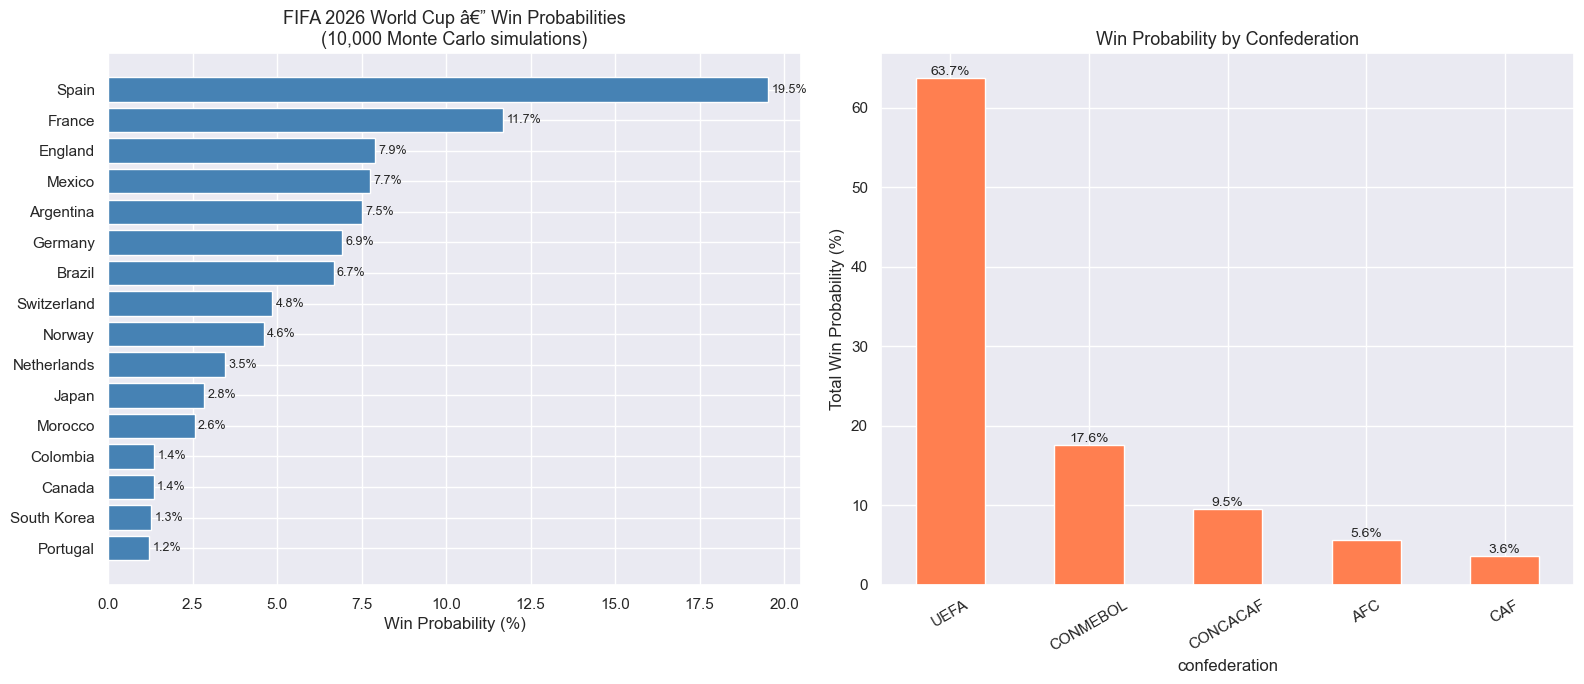

Chart saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 16 teams
top16 = win_probs.head(16)

# Bar chart
ax = axes[0]
bars = ax.barh(top16['team'][::-1], top16['win_pct'][::-1], color='steelblue')
ax.set_xlabel('Win Probability (%)')
ax.set_title('FIFA 2026 World Cup â€” Win Probabilities\n(10,000 Monte Carlo simulations)', fontsize=13)
for bar, val in zip(bars, top16['win_pct'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

# Confederation breakdown
ax2 = axes[1]
win_probs_conf = win_probs.copy()
win_probs_conf['confederation'] = win_probs_conf['team'].map(confs).fillna('UNKNOWN')
conf_totals = win_probs_conf.groupby('confederation')['win_pct'].sum().sort_values(ascending=False)
conf_totals.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Win Probability by Confederation', fontsize=13)
ax2.set_ylabel('Total Win Probability (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/wc2026_win_probs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [21]:
# Full results table
win_probs_full = win_probs.copy()
win_probs_full['confederation'] = win_probs_full['team'].map(confs).fillna('UNKNOWN')
win_probs_full['elo'] = win_probs_full['team'].map(elos).round(1)
win_probs_full = win_probs_full.merge(
    teams_2026[['team','group']], on='team', how='left'
)

print('Full results table:')
print(win_probs_full[['team','group','confederation','elo','wins','win_pct']].to_string(index=False))

# Save
win_probs_full.to_csv('../data/processed/wc2026_simulation_results.csv', index=False)
print('\nResults saved to data/processed/wc2026_simulation_results.csv')

Full results table:
          team group confederation    elo  wins  win_pct
         Spain     H          UEFA 2269.6  1952    19.52
        France     I          UEFA 2210.9  1168    11.68
       England     L          UEFA 2148.6   791     7.91
        Mexico     A      CONCACAF 1987.3   774     7.74
     Argentina     J      CONMEBOL 2227.0   750     7.50
       Germany     E          UEFA 2033.6   693     6.93
        Brazil     C      CONMEBOL 2085.9   667     6.67
   Switzerland     B          UEFA 2006.9   485     4.85
        Norway     I          UEFA 2023.0   460     4.60
   Netherlands     F          UEFA 2043.8   345     3.45
         Japan     F           AFC 2041.4   284     2.84
       Morocco     C           CAF 1989.1   256     2.56
      Colombia     K      CONMEBOL 2096.0   137     1.37
        Canada     B      CONCACAF 1917.3   135     1.35
   South Korea     A           AFC 1888.5   127     1.27
      Portugal     K          UEFA 2054.0   121     1.21
        Tur